What is the most optimal skill to learn for Data Engineers?

Methodolgy
Group skills to determine median slary and likrelihood of being in posting
Visualize median salary vs percent skill demand
(optional) Determine if certain technologies are prevalent


In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_DE_Canada  = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'Canada')].copy()

In [6]:
df_DE_Canada = df_DE_Canada.dropna(subset=['salary_year_avg'])

df_DE_Canada_exploded = df_DE_Canada.explode('job_skills')

df_DE_Canada_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
10270,125000.0,golang
10270,125000.0,kotlin
10270,125000.0,scala
10270,125000.0,python
10270,125000.0,aws


In [16]:
df_DE_skills = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False)

df_DE_skills = df_DE_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_DE_skills

,skill_count,median_salary
job_skills,,
sql,114,102550.5
python,112,100000.0
aws,87,125000.0
spark,58,102500.0
azure,56,94575.0
...,...,...
trello,1,90000.0
watson,1,101014.0
vue,1,90000.0


In [18]:
df_DE_skills = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False)

df_DE_skills = df_DE_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

df_job_count = len(df_DE_Canada)

df_DE_skills['skill_percent'] = df_DE_skills['skill_count']/ DE_job_count * 100

df_DE_skills

NameError: name 'DE_job_count' is not defined

In [24]:
df_DE_skills = df_DE_Canada_exploded.groupby('job_skills')['salary_year_avg'] \
                                     .agg(['count', 'median']) \
                                     .sort_values(by='count', ascending=False)

df_DE_skills = df_DE_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

job_count = len(df_DE_Canada)  # 👈 clean simple name

df_DE_skills['skill_percent'] = df_DE_skills['skill_count'] / job_count * 100

skill_percent = 5

df_DE_skills_high_demand = df_DE_skills[df_DE_skills['skill_percent'] > skill_percent]

df_DE_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,114,102550.5,68.263473
python,112,100000.0,67.065868
aws,87,125000.0,52.095808
spark,58,102500.0,34.730539
azure,56,94575.0,33.532934
...,...,...,...
trello,1,90000.0,0.598802
watson,1,101014.0,0.598802
vue,1,90000.0,0.598802


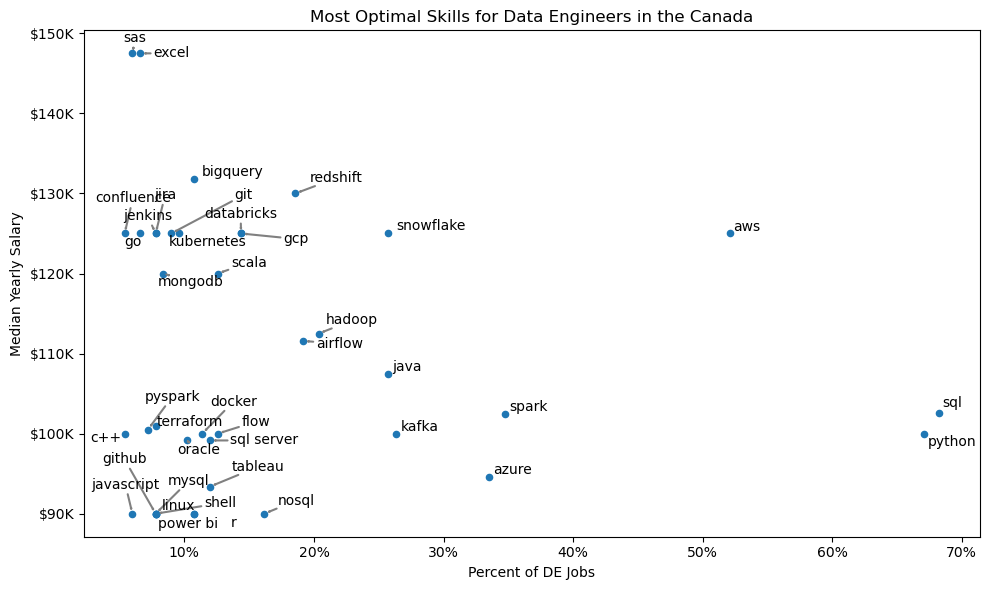

In [29]:

from adjustText import adjust_text

# Step 1 - Create plot
df_DE_skills_high_demand.plot(kind='scatter', x='skill_percent', y='median_salary', figsize=(10, 6))

# Step 2 - Add skill name labels ✅
texts = []
for i, txt in enumerate(df_DE_skills_high_demand.index):
    texts.append(plt.text(
        df_DE_skills_high_demand
    ['skill_percent'].iloc[i],
        df_DE_skills_high_demand
    ['median_salary'].iloc[i],
        txt  # ← this is the skill name e.g. 'python', 'sql'
    ))

# Step 3 - Prevent overlapping
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

# Step 4 - Labels and title
plt.xlabel('Percent of DE Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Engineers in the Canada')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()